# HaSpeeDe3-reloaded — Modello Decoder-Only

**Task:** Rilevamento dell'hate speech in tweet politici italiani (PolicyCorpusXL)  
**Dataset:** HaSpeeDe3 @ EVALITA 2023  
**Modello:** Minerva-1B con LoRA + feature contestuali  
**Metrica:** Media di F1-score sulle due classi (HS e non-HS)  
**Repository:** [therestar/HaSpeeDe3-reloaded](https://github.com/therestar/HaSpeeDe3-reloaded.git)

$$F1_{avg} = \frac{F1_{HS} + F1_{\neg HS}}{2}$$

---

## Perché Minerva-1B?

**Minerva** è la prima famiglia di LLM pre-addestrati **da zero** in italiano, sviluppata da Sapienza NLP
(Università La Sapienza di Roma) nel 2024 nell'ambito del progetto FAIR.
A differenza di GPT-2 italiano o GePpeTto, gli unici decoder italiani disponibili al momento di HaSpeeDe3, Minerva è addestrato su corpus moderni e bilanciati (CulturaX, ~100B token italiani).

---

## Struttura del notebook
1. Setup e dipendenze
2. Caricamento dei dataset
3. Analisi Esplorativa (EDA)
4. Pre-processing
5. Split Train / Validation
6. Data Augmentation (solo su train split)
7. Tokenizer e Dataset PyTorch
8. Definizione del Modello (Minerva-1B + LoRA)
9. Training
10. Ottimizzazione della Threshold
11. Valutazione sul Test Set
12. Generazione delle Predizioni


## 1. Setup e installazione dipendenze


In [ ]:
!pip install transformers==4.44.0 -q
!pip install datasets emoji scikit-learn -q
!pip install scikit-learn accelerate bitsandbytes peft -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import copy
import emoji
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from peft import get_peft_model, LoraConfig
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Seed per riproducibilità
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Dispositivo: GPU obbligatoria per Minerva-1B
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo in uso: {device}')


Dispositivo in uso: cuda


## 2. Caricamento dei dataset

Carico i 4 CSV e filtro i tweet politici.



In [ ]:
# Caricamento dei file
train_text = pd.read_csv('training_textual.csv')
test_text  = pd.read_csv('test_textual_gold.csv')
train_ctx  = pd.read_csv('training_contextual.csv')
test_ctx   = pd.read_csv('test_contextual.csv')

# Filtro solo i tweet politici come da specifica del task
train_ctx = train_ctx[train_ctx['dataset'] == 'training_politics']
test_ctx  = test_ctx[test_ctx['dataset'] == 'test_politics']

# Unisco testo e metadati tramite l'ID anonimizzato del tweet
train_df = train_text.merge(train_ctx, on='anonymized_tweet_id', suffixes=('', '_ctx'))
test_df  = test_text.merge(test_ctx,  on='anonymized_tweet_id', suffixes=('', '_ctx'))

print(f'Training set: {len(train_df)} campioni')
print(f'Test set:     {len(test_df)} campioni')


Training set: 5600 campioni
Test set:     1400 campioni


## 3. Analisi Esplorativa (EDA)


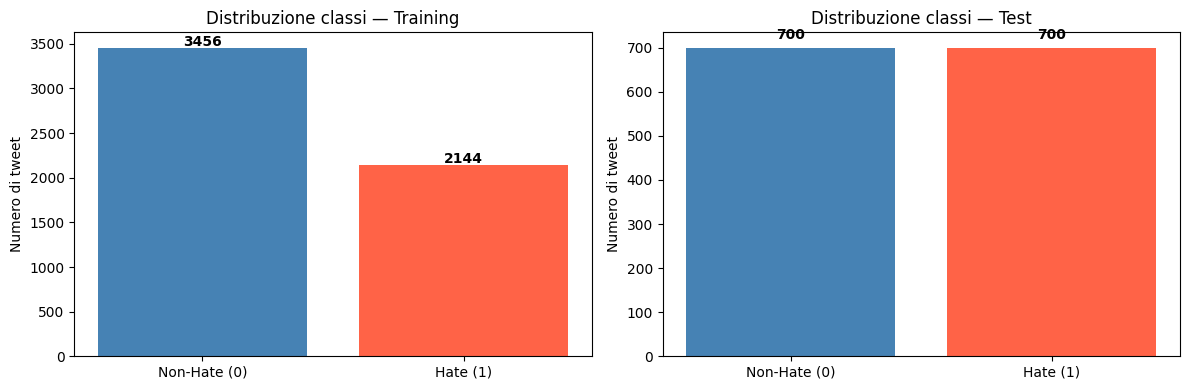


Distribuzione training:
label
0    0.617
1    0.383
Name: proportion, dtype: float64


In [ ]:
# --- Distribuzione delle classi ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes, [train_df, test_df], ['Training', 'Test']):
    counts = df['label'].value_counts()
    ax.bar(['Non-Hate (0)', 'Hate (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuzione classi — {title}')
    ax.set_ylabel('Numero di tweet')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDistribuzione training:')
print(train_df['label'].value_counts(normalize=True).round(3))


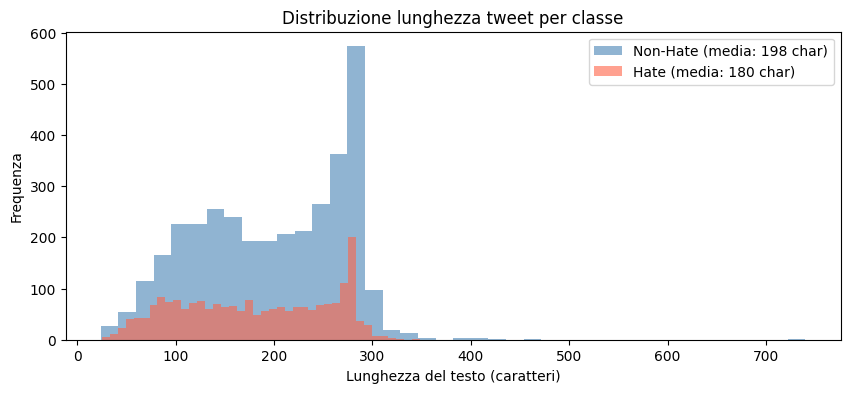

In [ ]:
# --- Lunghezza dei tweet ---
train_df['text_len'] = train_df['anonymized_text'].str.len()

plt.figure(figsize=(10, 4))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = train_df[train_df['label'] == label]['text_len']
    plt.hist(subset, bins=40, alpha=0.6, color=color,
             label=f'{"Hate" if label==1 else "Non-Hate"} (media: {subset.mean():.0f} char)')

plt.xlabel('Lunghezza del testo (caratteri)')
plt.ylabel('Frequenza')
plt.title('Distribuzione lunghezza tweet per classe')
plt.legend()
plt.show()


In [ ]:
# Feature contestuali vs label
CTX_FEATURES = ['retweet_count', 'favorite_count', 'is_reply', 'is_retweet', 'is_quote',
                'followers_count', 'friends_count', 'statuses_count']

print('Media delle feature contestuali per classe:')
print(train_df.groupby('label')[CTX_FEATURES].mean().round(2))


Media delle feature contestuali per classe:
       retweet_count  favorite_count  is_reply  is_retweet  is_quote  \
label                                                                  
0              20.19           73.84      0.19         0.0      0.04   
1              11.65           42.57      0.33         0.0      0.11   

       followers_count  friends_count  statuses_count  
label                                                  
0             17847.85        1817.89       107864.64  
1              3121.16        1743.36        44483.90  


## 4. Pre-processing

### Differenza rispetto al modello encoder-only
Minerva usa un tokenizer causale GPT-like con padding a sinistra (`padding_side='left'`).
Questo è fondamentale per i modelli decoder: il token di classificazione è l'ultimo token
della sequenza, quindi il padding deve stare a sinistra.

### Pre-processing testuale
- Rimozione `[URL]` e menzioni anonimizzate
- Conversione emoji in testo descrittivo
- Rimozione simbolo `#` mantenendo il testo
- Normalizzazione spazi

Il pre-processing viene applicato ora su `train_df` e `test_df` perché è una trasformazione
**deterministica** che non introduce data leakage.


In [ ]:
def preprocess_text(text):
    """
    Pulisce il testo del tweet per i modelli causali:
    - Rimuove [URL] e menzioni anonimizzate
    - Converte le emoji in testo descrittivo
    - Rimuove il simbolo # mantenendo il testo dell'hashtag
    - Normalizza spazi multipli
    """
    text = re.sub(r'\[URL\]', '', text)
    text = re.sub(r'\b\d{10,}\b', '', text)
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


train_df['clean_text'] = train_df['anonymized_text'].apply(preprocess_text)
test_df['clean_text']  = test_df['anonymized_text'].apply(preprocess_text)

print('Testo originale:')
print(train_df['anonymized_text'].iloc[:3])
print('\nTesto pulito:')
print(train_df['clean_text'].iloc[:3])


Testo originale:
0    @unknown Con tutte le denunce che si sta becca...
1    #PRESCRIZIONE : I (t)re magi hanno trovato l’a...
2    Il #m5s ha votato contro le #unionicivili addu...
Name: anonymized_text, dtype: object

Testo pulito:
0    @unknown Con tutte le denunce che si sta becca...
1    PRESCRIZIONE : I (t)re magi hanno trovato l’ac...
2    Il m5s ha votato contro le unionicivili adduce...
Name: clean_text, dtype: object


## 5. Split Train / Validation

Lo split viene eseguito prima dell'augmentation per evitare data leakage.

Se venisse effettuato prima dello split, varianti quasi identiche dello stesso tweet
potrebbero finire sia in `train_split` che in `val_split`, di conseguenza le metriche di validazione
risulterebbero ottimisticamente gonfiate.

Ordine corretto:
```
train_df  ->  [split 80/20]  ->  train_split  ->  [augmentation]  ->  train_aug
                             ->  val_split
```


In [ ]:
# Split stratificato 80/20 su train_df — PRIMA dell'augmentation
train_split, val_split = train_test_split(
    train_df, test_size=0.2, random_state=SEED, stratify=train_df['label']
)

print(f'Train split (pre-aug): {len(train_split)} campioni '
      f'(Hate: {train_split["label"].sum()}, Non-Hate: {(train_split["label"]==0).sum()})')
print(f'Val split:             {len(val_split)} campioni '
      f'(Hate: {val_split["label"].sum()}, Non-Hate: {(val_split["label"]==0).sum()})')


Train split (pre-aug): 4480 campioni (Hate: 1715, Non-Hate: 2765)
Val split:             1120 campioni (Hate: 429, Non-Hate: 691)


## 6. Data Augmentation

Applico augmentation solo sulla classe Hate del `train_split`
per bilanciare le classi senza contaminare il validation set.

### Tecniche usate (text-level, language-agnostic)
1. **Random Word Swap** scambia casualmente una coppia di parole adiacenti
2. **Random Word Deletion** rimuove casualmente una parola con probabilità `p=0.1`

> **Nota**: `StandardScaler` e mediane vengono calcolati su `train_aug` (post-augmentation)
> e solo applicati (`.transform`) su val e test.


In [ ]:
def random_word_swap(text, n=1):
    """Scambia n coppie di parole adiacenti casuali."""
    words = text.split()
    if len(words) < 2:
        return text
    for _ in range(n):
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx + 1] = words[idx + 1], words[idx]
    return ' '.join(words)


def random_word_deletion(text, p=0.1):
    """Elimina ogni parola con probabilità p. Mantiene almeno 1 parola."""
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words) if new_words else random.choice(words)


def augment_text(text):
    """Applica casualmente uno dei due metodi di augmentation."""
    if random.random() < 0.5:
        return random_word_swap(text, n=1)
    else:
        return random_word_deletion(text, p=0.1)


# Augmentation SOLO su train_split sulla classe Hate
random.seed(SEED)
n_hate    = (train_split['label'] == 1).sum()
n_nonhate = (train_split['label'] == 0).sum()
gap       = n_nonhate - n_hate
print(f"Prima dell'augmentation → Non-Hate: {n_nonhate} | Hate: {n_hate} | Gap: {gap}")

hate_samples = train_split[train_split['label'] == 1].sample(
    n=gap, replace=True, random_state=SEED).copy()
hate_samples['clean_text'] = hate_samples['clean_text'].apply(augment_text)
hate_samples['augmented']  = True

train_split_marked              = train_split.copy()
train_split_marked['augmented'] = False
train_aug = pd.concat([train_split_marked, hate_samples], ignore_index=True).sample(
    frac=1, random_state=SEED).reset_index(drop=True)

print(f"Dopo l'augmentation  → Non-Hate: {(train_aug['label']==0).sum()} | "
      f"Hate: {(train_aug['label']==1).sum()}")
print(f'Totale campioni train: {len(train_aug)}')

# --- Feature contestuali: mediane e scaler fittati su train_aug ---
medians = train_aug[CTX_FEATURES].median()
train_aug[CTX_FEATURES]  = train_aug[CTX_FEATURES].fillna(medians)
val_split[CTX_FEATURES]  = val_split[CTX_FEATURES].fillna(medians)
test_df[CTX_FEATURES]    = test_df[CTX_FEATURES].fillna(medians)

scaler          = StandardScaler()
train_ctx_arr   = scaler.fit_transform(train_aug[CTX_FEATURES])
val_ctx_arr     = scaler.transform(val_split[CTX_FEATURES])
test_ctx_arr    = scaler.transform(test_df[CTX_FEATURES])

print(f'\nFeature contestuali: {CTX_FEATURES}')


Prima dell'augmentation → Non-Hate: 2765 | Hate: 1715 | Gap: 1050
Dopo l'augmentation  → Non-Hate: 2765 | Hate: 2765
Totale campioni train: 5530

Feature contestuali: ['retweet_count', 'favorite_count', 'is_reply', 'is_retweet', 'is_quote', 'followers_count', 'friends_count', 'statuses_count']


## 7. Tokenizer e Dataset PyTorch

### Padding a sinistra per i modelli causali
Nei modelli decoder-only, la classificazione si basa sull'ultimo token della sequenza.
Se il padding fosse a destra, l'ultimo token sarebbe `[PAD]` e non un token reale.

Utilizzo `tokenizer.padding_side = 'left'`.


In [ ]:
# Caricamento tokenizer
MODEL_NAME = 'sapienzanlp/Minerva-1B-base-v1.0'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# FONDAMENTALE padding a sinistra
tokenizer.padding_side = 'left'

# Minerva-1B non ha un pad_token di default, uso eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f'pad_token impostato a: {tokenizer.pad_token}')

print(f'Modello: {MODEL_NAME}')
print(f'Vocabolario: {tokenizer.vocab_size} token')
print(f'Padding side: {tokenizer.padding_side}')


tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/795k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

pad_token impostato a: </s>
Modello: sapienzanlp/Minerva-1B-base-v1.0
Vocabolario: 32768 token
Padding side: left


In [ ]:
class HateSpeechDataset(Dataset):
    """
    Dataset PyTorch per hate speech detection con decoder-only.
    Padding a sinistra, classificazione sull'ultimo token.
    """
    def __init__(self, texts, ctx_features, labels, tokenizer, max_len):
        self.texts        = texts
        self.ctx_features = ctx_features
        self.labels       = labels
        self.tokenizer    = tokenizer
        self.max_len      = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'ctx_features':   torch.tensor(self.ctx_features[idx], dtype=torch.float),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


BATCH_SIZE = 8

train_dataset = HateSpeechDataset(
    train_aug['clean_text'].tolist(), train_ctx_arr,
    train_aug['label'].tolist(), tokenizer, MAX_LEN)

val_dataset = HateSpeechDataset(
    val_split['clean_text'].tolist(), val_ctx_arr,
    val_split['label'].tolist(), tokenizer, MAX_LEN)

test_dataset = HateSpeechDataset(
    test_df['clean_text'].tolist(), test_ctx_arr,
    test_df['label'].tolist(), tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')


Batch train: 692 | val: 140 | test: 175


## 8. Definizione del Modello (Minerva-1B + LoRA)

### Perché LoRA?

Il problema è che il fine-tuning di 940 milioni di parametri su circa 5000 esempi porta lo score F1 di train a 0.997 mentre la val loss aumenta.

**LoRA** (Low-Rank Adaptation) congela il 99% dei pesi del modello e allena solo gli strati di attention:

Con r=64 e target modules estesi all'attention e agli strati MLP (gate_proj, up_proj, down_proj), i parametri trainabili sono ~42M, bilanciando capacità adattiva e regolarizzazione.

### Architettura
1. Minerva-1B (backbone congelato) + adapter LoRA su q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
2. **Proiezione contestuale** → `Linear(8 → 64)` + ReLU + Dropout(0.3)
3. **Concatenazione** hidden state ultimo token + ctx embedding
4. **Classificatore** → `Linear(hidden_size+64 → 256)` → ReLU → `Linear(256 → 2)`


In [ ]:
class MinervaHateSpeechClassifierLoRA(nn.Module):
    """
    Classificatore Minerva-1B con LoRA per il fine-tuning efficiente.

    LoRA congela il backbone e aggiorna solo ~42M parametri (rank-64 sulle attention),
    riducendo drasticamente l'overfitting rispetto al full fine-tuning.
    """
    def __init__(self, model_name, n_ctx_features, dropout=0.3):
        super().__init__()

        # 1. Carica il backbone base (senza classification head)
        base_lm = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.bfloat16,  # stabile come float32, meno VRAM
            device_map='auto'
        )

        # 2. Applica LoRA agli strati di attention
        lora_config = LoraConfig(
            r=64,
            lora_alpha=128,          # sempre 2*r
            lora_dropout=0.05,
            target_modules=[
                'q_proj', 'k_proj', 'v_proj', 'o_proj',  # attention
                'gate_proj', 'up_proj', 'down_proj'        # MLP
            ],
            bias='none',
        )
        self.lm = get_peft_model(base_lm, lora_config)

        # 3. Cast adapter LoRA a bfloat16 per coerenza con il backbone
        for name, param in self.lm.named_parameters():
            if param.requires_grad:
                param.data = param.data.to(torch.bfloat16)

        lm_device = next(self.lm.parameters()).device
        lm_dtype  = next(self.lm.parameters()).dtype
        hidden_size = self.lm.config.hidden_size

        # 4. Proiezione feature contestuali
        self.ctx_projection = nn.Sequential(
            nn.Linear(n_ctx_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        ).to(device=lm_device, dtype=lm_dtype)

        # 5. Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        ).to(device=lm_device, dtype=lm_dtype)

    def forward(self, input_ids, attention_mask, ctx_features):
        outputs = self.lm(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        # Hidden state dell'ULTIMO token (padding a sinistra -> sempre token reale)
        last_hidden  = outputs.last_hidden_state[:, -1, :]   # [batch, hidden_size]
        ctx_features = ctx_features.to(last_hidden.dtype)
        ctx_emb      = self.ctx_projection(ctx_features)      # [batch, 64]
        combined     = torch.cat([last_hidden, ctx_emb], dim=1)
        return self.classifier(combined)                       # [batch, 2]


# Istanza del modello
print('Caricamento Minerva-1B con LoRA...')
model = MinervaHateSpeechClassifierLoRA(
    model_name     = MODEL_NAME,
    n_ctx_features = len(CTX_FEATURES)
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f'\nParametri totali:     {total_params:,}')
print(f'Parametri trainabili: {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)')
print(f'Parametri congelati:  {frozen_params:,}  ({100*frozen_params/total_params:.2f}%)')


Caricamento Minerva-1B con LoRA...


config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.01G [00:00<?, ?B/s]


Parametri totali:     982,076,738
Parametri trainabili: 42,485,058  (4.33%)
Parametri congelati:  939,591,680  (95.67%)


## 9. Training

### Iperparametri
- **LR backbone (LoRA adapters)**: 8e-6
- **LR head**: 2e-4
- **Weight decay**: 0.05
- **Gradient accumulation**: 2 step (batch effettivo = 16)
- **Epoche massime**: 15 con early stopping (patience=3)
- **Class weight**: $w_{hate} = N_{non-hate}/N_{hate}$ per compensare lo sbilanciamento residuo


In [ ]:
MAX_EPOCHS = 15
PATIENCE   = 2
LR_LM      = 8e-6
LR_HEAD    = 2e-4
ACCUMULATION_STEPS = 2

optimizer = AdamW([
    {'params': model.lm.parameters(),             'lr': LR_LM},
    {'params': model.ctx_projection.parameters(), 'lr': LR_HEAD},
    {'params': model.classifier.parameters(),     'lr': LR_HEAD}
], weight_decay=0.05)

total_steps  = (len(train_loader) // ACCUMULATION_STEPS) * MAX_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Class weight calcolato su train_aug (post-augmentation, no data leakage)
n_nonhate    = (train_aug['label'] == 0).sum()
n_hate       = (train_aug['label'] == 1).sum()
class_weight = torch.tensor([
    n_hate    / n_nonhate,   # peso Non-Hate
    n_nonhate / n_hate       # peso Hate
], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weight)
print(f'Class weight → Non-Hate: {class_weight[0]:.4f} | Hate: {class_weight[1]:.4f}')
print(f'MAX_EPOCHS={MAX_EPOCHS} | PATIENCE={PATIENCE} | ACCUMULATION_STEPS={ACCUMULATION_STEPS}')


Class weight → Non-Hate: 1.0000 | Hate: 1.0000
MAX_EPOCHS=15 | PATIENCE=2 | ACCUMULATION_STEPS=2


In [ ]:
def run_epoch(model, loader, optimizer, scheduler, criterion, device,
              accumulation_steps=1, train=True):
    """
    Esegue un'epoca di training o validazione.
    - train=True:  aggiorna i pesi con gradient accumulation
    - train=False: solo forward pass (no_grad)
    """
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    if train:
        optimizer.zero_grad()

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for step, batch in enumerate(loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ctx_features   = batch['ctx_features'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask, ctx_features)
            loss   = criterion(logits.float(), labels)

            if train:
                (loss / accumulation_steps).backward()
                total_loss += loss.item()
                if (step + 1) % accumulation_steps == 0:
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
            else:
                total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1_avg   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1_avg


In [ ]:
history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
best_val_f1       = 0.0
best_model_wts    = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
best_epoch        = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_f1 = run_epoch(model, train_loader, optimizer, scheduler,
                                     criterion, device, ACCUMULATION_STEPS, train=True)
    val_loss,   val_f1   = run_epoch(model, val_loader,   None, None,
                                     criterion, device, train=False)

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    improved = '✓' if val_f1 > best_val_f1 else ' '
    print(f'Ep {epoch:02d}/{MAX_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | '
          f'Val Loss: {val_loss:.4f} F1: {val_f1:.4f} {improved}')

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        best_model_wts    = copy.deepcopy(model.state_dict())
        best_epoch        = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping alla epoca {epoch} '
                  f'(nessun miglioramento per {PATIENCE} epoche consecutive)')
            break

model.load_state_dict(best_model_wts)
print(f'\nMiglior modello: epoca {best_epoch} — Val F1: {best_val_f1:.4f}')


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


Ep 01/15 | Train Loss: 0.5899 F1: 0.6577 | Val Loss: 0.3937 F1: 0.8245 ✓
Ep 02/15 | Train Loss: 0.3171 F1: 0.8662 | Val Loss: 0.2795 F1: 0.8884 ✓
Ep 03/15 | Train Loss: 0.1851 F1: 0.9320 | Val Loss: 0.3411 F1: 0.8910 ✓
Ep 04/15 | Train Loss: 0.1138 F1: 0.9624 | Val Loss: 0.3958 F1: 0.8900  
Ep 05/15 | Train Loss: 0.0674 F1: 0.9817 | Val Loss: 0.5155 F1: 0.8860  

Early stopping alla epoca 5 (nessun miglioramento per 2 epoche consecutive)

Miglior modello: epoca 3 — Val F1: 0.8910


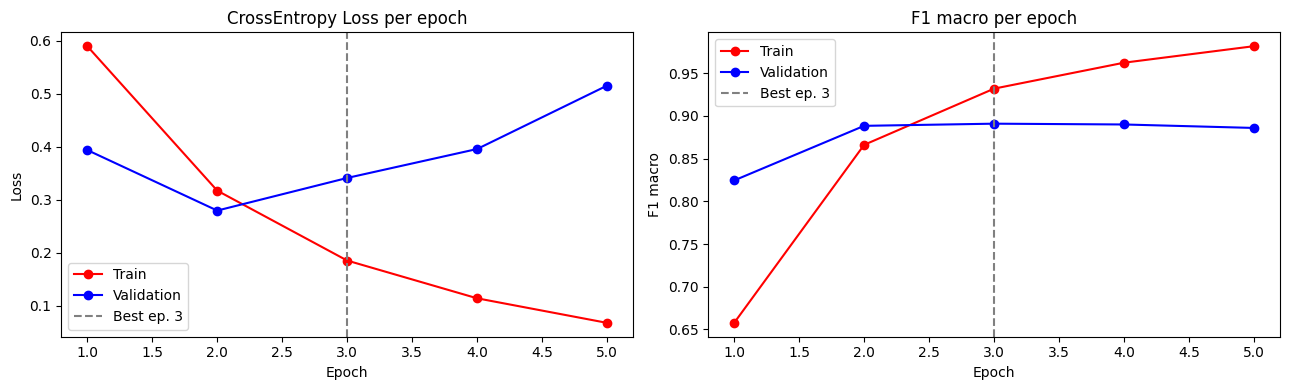

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='red',    label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'o-', color='blue', label='Validation')
axes[0].axvline(best_epoch, linestyle='--', color='gray', label=f'Best ep. {best_epoch}')
axes[0].set_title('CrossEntropy Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_f1'], 'o-', color='red',    label='Train')
axes[1].plot(epochs_range, history['val_f1'],   'o-', color='blue', label='Validation')
axes[1].axvline(best_epoch, linestyle='--', color='gray', label=f'Best ep. {best_epoch}')
axes[1].set_title('F1 macro per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 macro')
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Ottimizzazione della Threshold

Invece di usare `argmax` (equivalente a threshold=0.5 sulle probabilità softmax),
effettuo uno sweep sul validation set per trovare la threshold ottimale.


Threshold ottimale: 0.65  →  F1_val = 0.8996
F1_val con threshold 0.50: 0.8910


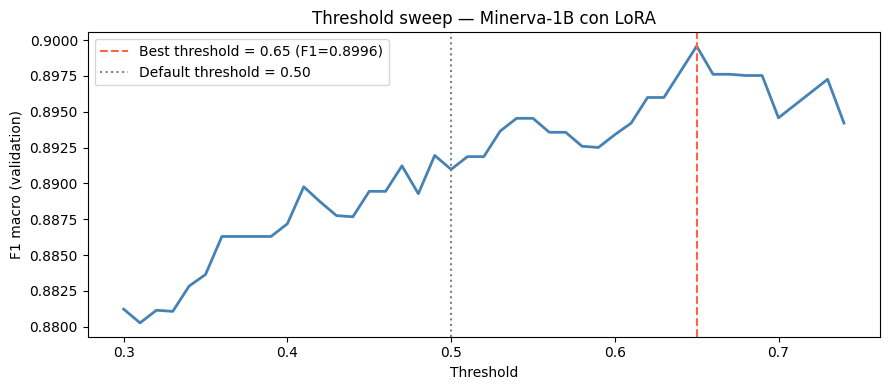

In [ ]:
def get_probabilities(model, loader, device):
    """Raccoglie le probabilità P(Hate) via softmax sul loader specificato."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            ctx_features   = batch['ctx_features'].to(device)
            labels         = batch['label']
            logits = model(input_ids, attention_mask, ctx_features)
            probs  = F.softmax(logits.float(), dim=1)[:, 1]  # P(Hate)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)


# Sweep sul validation set
val_probs, val_labels_arr = get_probabilities(model, val_loader, device)

thresholds = np.arange(0.30, 0.75, 0.01)
f1_scores  = []
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(val_labels_arr, preds, average='macro', zero_division=0))

best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]
best_f1_val    = f1_scores[best_idx]

print(f'Threshold ottimale: {BEST_THRESHOLD:.2f}  →  F1_val = {best_f1_val:.4f}')
print(f'F1_val con threshold 0.50: {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(BEST_THRESHOLD, color='tomato', linestyle='--',
            label=f'Best threshold = {BEST_THRESHOLD:.2f} (F1={best_f1_val:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default threshold = 0.50')
plt.xlabel('Threshold')
plt.ylabel('F1 macro (validation)')
plt.title('Threshold sweep — Minerva-1B con LoRA')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Valutazione sul Test Set

Valuto con la metrica ufficiale del task e confronto con i risultati del paper.

| Sistema | F1_avg |
|---|---|
| Baseline SVM | 0.8457 |
| CHILab (AlBERTo) | 0.8510 |
| BERTicelli (UmBERTo) | 0.8976 |
| extremITA (IT5 + LLaMA) | 0.9030 |
| Best system (odang4) | 0.9128 |
| Minerva-1B base (no LoRA) | 0.8791 |
| Minerva-1B + LoRA |  |


In [ ]:
test_probs, test_labels_arr = get_probabilities(model, test_loader, device)
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)
test_f1    = f1_score(test_labels_arr, test_preds, average='macro', zero_division=0)

print('=' * 55)
print(f'Threshold usata:  {BEST_THRESHOLD:.2f}')
print(f'F1 avg sul test:  {test_f1:.4f}')
print('=' * 55)
print()
print('Report dettagliato:')
print(classification_report(test_labels_arr, test_preds,
                             target_names=['Non-Hate (0)', 'Hate (1)']))

print('\n--- Confronto con i risultati del paper HaSpeeDe3 ---')
print(f'Baseline SVM:                          F1_avg = 0.8457')
print(f'CHILab (AlBERTo):                      F1_avg = 0.8510')
print(f'BERTicelli (UmBERTo):                  F1_avg ≈ 0.8976')
print(f'extremITA (IT5 + LLaMA):               F1_avg ≈ 0.9030')
print(f'Best system (odang4):                  F1_avg = 0.9128')
print(f'Minerva-1B base (no LoRA):             F1_avg = 0.8791')
print(f'Minerva-1B + LoRA:                     F1_avg = {test_f1:.4f}  ←')


Threshold usata:  0.65
F1 avg sul test:  0.8985

Report dettagliato:
              precision    recall  f1-score   support

Non-Hate (0)       0.88      0.92      0.90       700
    Hate (1)       0.92      0.88      0.90       700

    accuracy                           0.90      1400
   macro avg       0.90      0.90      0.90      1400
weighted avg       0.90      0.90      0.90      1400


--- Confronto con i risultati del paper HaSpeeDe3 ---
Baseline SVM:                          F1_avg = 0.8457
CHILab (AlBERTo):                      F1_avg = 0.8510
BERTicelli (UmBERTo):                  F1_avg ≈ 0.8976
extremITA (IT5 + LLaMA):               F1_avg ≈ 0.9030
Best system (odang4):                  F1_avg = 0.9128
Minerva-1B base (no LoRA):             F1_avg = 0.8791
Minerva-1B + LoRA:                     F1_avg = 0.8985  ←


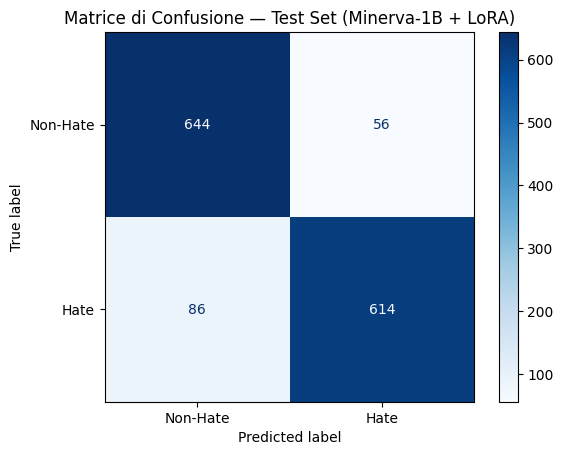

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(test_labels_arr, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hate', 'Hate'])
disp.plot(cmap='Blues')
plt.title('Matrice di Confusione — Test Set (Minerva-1B + LoRA)')
plt.show()


## 12. Generazione delle Predizioni


In [ ]:
results_df = test_df[['anonymized_tweet_id', 'anonymized_text', 'label']].copy()
results_df['prediction'] = test_preds
results_df['confidence'] = test_probs
results_df['correct']    = (results_df['label'] == results_df['prediction']).astype(int)

results_df.to_csv('predictions_decoder_only.csv', index=False)
print('Predizioni salvate in predictions_decoder_only.csv')
print(f'\nAccuracy: {results_df["correct"].mean():.4f}')
print(results_df.head())


Predizioni salvate in predictions_decoder_only.csv

Accuracy: 0.8986
   anonymized_tweet_id                                    anonymized_text  \
0      424801448454884  questo anno #babbonatale portato giocattolo it...   
1      775194088981616  Adesso che in mezzo alla strada grazie al verg...   
2      386928936347190  Circondatevi di persone che non sono diventate...   
3      957546674360002  Seriamente, per capire, se un ladro mi entra i...   
4      530526299555950  Che poi è probabile che #Spataro non sia potut...   

   label  prediction  confidence  correct  
0      1           0    0.009268        0  
1      1           1    0.756358        1  
2      0           0    0.004134        1  
3      0           0    0.000112        1  
4      0           0    0.164114        1  


In [ ]:
fp = results_df[(results_df['label'] == 0) & (results_df['prediction'] == 1)]
print(f'Falsi Positivi: {len(fp)}')
print(fp['anonymized_text'].head(3).to_string())

print()

fn = results_df[(results_df['label'] == 1) & (results_df['prediction'] == 0)]
print(f'Falsi Negativi: {len(fn)}')
print(fn['anonymized_text'].head(3).to_string())


Falsi Positivi: 56
16     Per @49053734760014 e Miccichè sta  bene dare ...
65     Il #m5s, con il solito sistema del #rancore gi...
111    #Travaglio non deve essere #grillino però tutt...

Falsi Negativi: 86
0     questo anno #babbonatale portato giocattolo it...
36    Ma perché un #tribunaledeiministri ? Non c’è f...
43    La cosa bella per un premier che non conta un ...


## Conclusioni

### Confronto encoder-only vs decoder-only

**Perché l'encoder-only performa meglio:**  
L'attention bidirezionale è strutturalmente più adatta alla classificazione: il token `[CLS]`
vede l'intero contesto simultaneamente. Il decoder vede solo i token precedenti (attention causale),
il che riduce la ricchezza della rappresentazione usata per classificare.
LoRA mitiga l'overfitting ma non cambia questo vantaggio architetturale intrinseco dell'encoder.
